In [1]:
import globals as gl
import pickle

import os
import numpy as np
import sys

import PcmPy as pcm

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa

import warnings
warnings.filterwarnings("ignore")

plt.close('all')
plt.style.use('default')


Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


 # **Cue representation**

## **Planning**

Text(0.5, 0.98, 'Planning, average distances across participants (N=5), hemisphere:L')

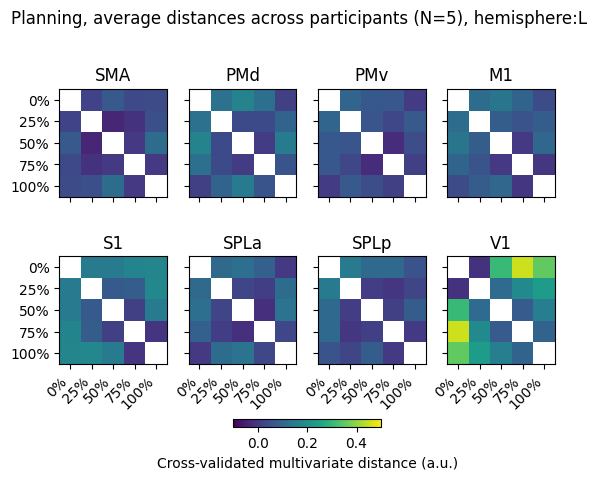

In [4]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Planning, average distances across participants (N={len(snS)}), hemisphere:{Hem}')

## **Execution**

KeyboardInterrupt: 

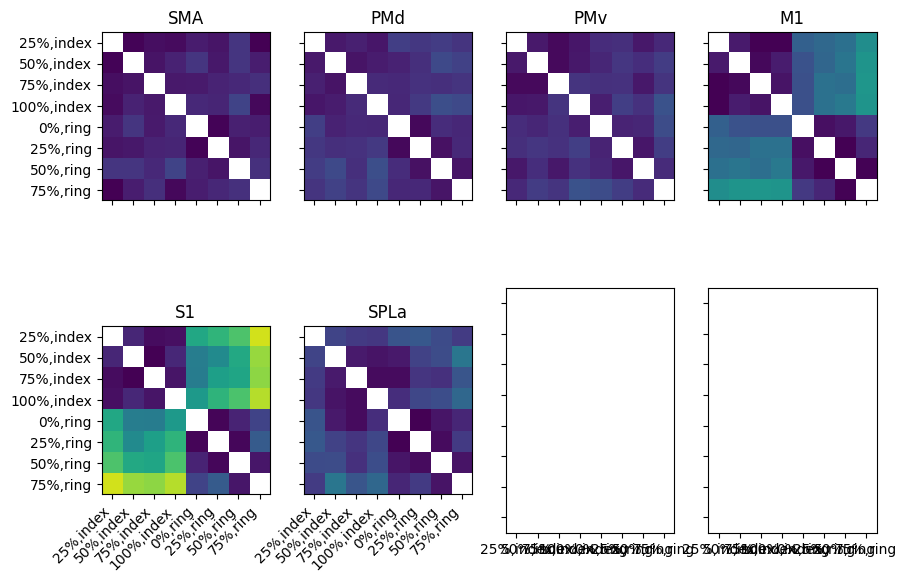

In [6]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1.5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Execution, average distances across participants (N={len(snS)}), hemisphere:{Hem}')


In [6]:
A = np.load('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/features.plan.npy')

T_in = pd.read_pickle('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/T_cv.plan.glm12.L.SMA.pkl')
T_cv = pd.read_pickle('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/T_in.plan.glm12.L.SMA.pkl')
T_gr = pd.read_pickle('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/T_gr.plan.glm12.L.SMA.pkl')

with open('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/theta_in.plan.glm12.L.SMA.pkl', 'rb') as f:
    theta_in = pickle.load(f)

with open('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/theta_cv.plan.glm12.L.SMA.pkl', 'rb') as f:
    theta_cv = pickle.load(f)

with open('/Volumes/Diedrichsen_data$/data/SensoriMotorPrediction/smp2/pcm/theta_in.plan.glm12.L.SMA.pkl', 'rb') as f:
    theta_gr = pickle.load(f)
# pcm.model_plot(T_cv.likelihood, null_model='null', noise_ceiling='ceil')